# California Wildfire PM2.5 Pollution Risk Classifier on Prison and Detention Facilities

## Part 3: Pre-Analysis and Finalizing Features Before Inputting into Model

**EDA, One Hot Encoding and Observing Feature Dependency**:
1. EDA
2. One Hot Encoding Facility Types
3. Correlation Matrix

In [1]:
import os
import datetime 

import numpy as np
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Obtaining Path files to the data in data folder

directory_name = os.getcwd()
directory_path = Path(directory_name)

# Loading final engineering dataframe: 
final_feature_engineered_data = pd.read_pickle(directory_path.joinpath('data/final_feature_engineering_features.pkl'))

## EDA on Feature Engineered DataFrame

In [3]:
final_feature_engineered_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5237 entries, 0 to 5236
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Institution Name                5237 non-null   object 
 1   Date                            5237 non-null   object 
 2   min_distance_km                 5237 non-null   float64
 3   max_magnitude_score             5237 non-null   float64
 4   total_magnitude                 5237 non-null   float64
 5   max_acres                       5237 non-null   float32
 6   total_acres                     5237 non-null   float32
 7   intersecting_fires              5237 non-null   float64
 8   number_of_fires_at_10km         5237 non-null   float64
 9   number_of_fires_at_50km         5237 non-null   float64
 10  number_of_fires_at_100km        5237 non-null   float64
 11  firms_50km_max_frp              5237 non-null   float64
 12  firms_50km_total_frp            52

In [4]:
# Count of NA values in dataframe
final_feature_engineered_data.isna().sum()

Institution Name                     0
Date                                 0
min_distance_km                      0
max_magnitude_score                  0
total_magnitude                      0
max_acres                            0
total_acres                          0
intersecting_fires                   0
number_of_fires_at_10km              0
number_of_fires_at_50km              0
number_of_fires_at_100km             0
firms_50km_max_frp                   0
firms_50km_total_frp                 0
firms_50km_total_thermal_score       0
firms_50km_fire_day_count            0
firms_50km_pixel_count               0
firms_50km_night_fire_ratio          0
fire_50km_elevation_mean          2018
fire_50km_elevation_max           2018
facility_elevation                1983
5km_buffer_elevation              1983
valley_index                      1983
ID                                   0
max_pm_conc                       1306
avg_pm_conc                       1306
max_aqi                  

In [5]:
# Count of 0 values in dataframe
(final_feature_engineered_data == 0).sum()

Institution Name                     0
Date                                 0
min_distance_km                   2541
max_magnitude_score               2536
total_magnitude                   2536
max_acres                         2536
total_acres                       2536
intersecting_fires                5231
number_of_fires_at_10km           5038
number_of_fires_at_50km           3611
number_of_fires_at_100km          2834
firms_50km_max_frp                1983
firms_50km_total_frp              1983
firms_50km_total_thermal_score    1983
firms_50km_fire_day_count         1983
firms_50km_pixel_count            1983
firms_50km_night_fire_ratio       4646
fire_50km_elevation_mean             0
fire_50km_elevation_max              0
facility_elevation                   0
5km_buffer_elevation                 0
valley_index                         0
ID                                  69
max_pm_conc                          0
avg_pm_conc                          0
max_aqi                  

In [6]:
# Removing columns that are missing 80% non-structural data
finalizing_features = final_feature_engineered_data.copy()
finalizing_features.drop(columns='intersecting_fires', inplace=True)

In [7]:
# Inspecting NA PM 2.5 date values
missing_pm_values_df = finalizing_features[finalizing_features['max_pm_conc'].isna()]
missing_pm_values_sorted = missing_pm_values_df.sort_values(by="Date", ascending=True)
missing_pm_values_sorted['Date'].value_counts().head(40)

Date
2020-12    79
2020-11    79
2020-10    79
2021-11    77
2021-10    77
2021-12    77
2022-10    72
2022-12    72
2022-11    72
2024-12    71
2023-10    70
2023-11    70
2023-12    70
2024-10    70
2024-11    70
2020-09    12
2020-02     7
2020-01     7
2021-01     7
2020-05     7
2020-04     7
2021-05     7
2021-04     7
2020-03     7
2020-06     7
2020-07     7
2020-08     7
2021-02     7
2021-03     7
2022-07     6
2021-07     6
2022-03     6
2022-06     6
2022-05     6
2021-06     6
2022-01     6
2022-02     6
2022-04     6
2022-08     4
2021-09     3
Name: count, dtype: int64

In [8]:
# Inspecting facilities with missing PM 2.5 data
missing_pm_values_sorted['Institution Name'].value_counts().head(40)

Institution Name
Intermountain #22                            64
Ironwood State Prison (ISP)                  35
Chuckawalla Valley State Prison (CVSP)       31
High Desert State Prison (HDSP)              30
Antelope #25                                 30
California Correctional Center (CCC)         30
Parlin Fork #6                               21
Eel River #31                                17
Sugar Pine #9                                16
Deadwood #23                                 16
Konocti #27                                  16
California Correctional Institution (CCI)    16
Calipatria State Prison (CAL)                16
California City Correctional Facility        16
Washington Ridge #44                         15
Cuesta #24                                   15
Vallecito #1                                 15
Adelanto ICE Processing Center               15
Holton #16                                   15
Ventura Training Center (VTC)                15
Valley State Prison (VS

## Fixing Missing Elevation and NA Data

In [9]:
# Setting each facility_elevation, buffer, and valley index to each facility
missing_fac_elevation_data = finalizing_features[finalizing_features['facility_elevation'].isna()]
nonmissing_fac_elevation_data = finalizing_features[(finalizing_features['facility_elevation'].notna())].copy()
single_fac_elevation_data = nonmissing_fac_elevation_data.drop_duplicates(subset='Institution Name')

for index, row in missing_fac_elevation_data.iterrows():
    filter_by_fac = single_fac_elevation_data[single_fac_elevation_data['Institution Name'] == row['Institution Name']]
    finalizing_features.iloc[index, 18:21]= filter_by_fac[['facility_elevation', '5km_buffer_elevation', 'valley_index']]

In [10]:
# Fixing NA fire_50km_elevation_mean and fire_50km_elevation_max
finalizing_features.fillna({'fire_50km_elevation_mean': 0, 'fire_50km_elevation_max': 0}, inplace=True)

## One Hot Encoding 

In [11]:
# OHE Facility Types
enc = OneHotEncoder()
enc.fit(finalizing_features[['facility_type']])
enc_fac_data = enc.transform(finalizing_features[['facility_type']]).toarray()
enc_fac_df = pd.DataFrame(data=enc_fac_data, columns=enc.get_feature_names_out(), index=finalizing_features.index) 

finalizing_features_ohe_one = finalizing_features.join(enc_fac_df).copy()
finalizing_features_ohe_one.drop(columns='facility_type', inplace=True)
finalizing_features_ohe_one

,Institution Name,Date,min_distance_km,max_magnitude_score,total_magnitude,max_acres,total_acres,number_of_fires_at_10km,number_of_fires_at_50km,number_of_fires_at_100km,...,avg_monitor_dist,avg_monitor_count,sensor_type,no2_co_ratio,aerosol_co_ratio,has_population_data,population_per_area,facility_type_Adult Facility,facility_type_Conservation Camp,facility_type_ICE Detention
0,Avenal State Prison (ASP),2024-09,20.445998,11.512470,12.723598,17614.501953,18397.677734,0.0,3.0,10.0,...,24680.020379,1.00000,epa_sensor,0.002487,0.052432,1,0.010326,1.0,0.0,0.0
1,Avenal State Prison (ASP),2024-08,47.761541,0.013578,0.027881,93.720016,164.857498,0.0,1.0,6.0,...,24680.020379,1.00000,epa_sensor,0.002738,0.042924,1,0.010816,1.0,0.0,0.0
2,Avenal State Prison (ASP),2024-10,58.614185,0.002694,0.009234,14.273177,56.154938,0.0,0.0,6.0,...,NaN,NaN,NaN,0.002230,0.065429,1,0.009901,1.0,0.0,0.0
3,Avenal State Prison (ASP),2024-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,24680.020379,1.00000,epa_sensor,0.001546,-0.089753,1,0.011514,1.0,0.0,0.0
4,Avenal State Prison (ASP),2024-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,24680.020379,1.00000,epa_sensor,0.001765,-0.166920,1,0.011707,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5232,Otay Mesa Detention Center,2024-09,52.603041,0.084247,0.098347,856.154236,909.404968,0.0,0.0,3.0,...,498.496428,8.00000,epa_sensor,0.002989,0.187392,1,0.047310,0.0,0.0,1.0
5233,Otay Mesa Detention Center,2024-10,47.047573,0.167037,0.201092,411.360443,489.978394,0.0,2.0,0.0,...,NaN,NaN,NaN,0.003416,0.297662,1,0.050322,0.0,0.0,1.0
5234,Otay Mesa Detention Center,2024-11,1.493342,11.075086,11.122651,68.851067,155.610016,1.0,1.0,2.0,...,NaN,NaN,NaN,0.004138,0.392720,1,0.052000,0.0,0.0,1.0
5235,Otay Mesa Detention Center,2024-12,20.013669,0.050034,0.050034,22.093618,22.093618,0.0,1.0,0.0,...,NaN,NaN,NaN,0.004539,-1.881984,1,0.052343,0.0,0.0,1.0


In [12]:
# Considering there are 1306 missing PM 2.5 values, there are no sensor types for these missing values as well. 
# If adding missing PM 2.5 values to model, it would be best to drop the sensor type column
finalizing_features_ohe_one.drop(columns=['sensor_type'], inplace=True)
finalizing_features_ohe_one

,Institution Name,Date,min_distance_km,max_magnitude_score,total_magnitude,max_acres,total_acres,number_of_fires_at_10km,number_of_fires_at_50km,number_of_fires_at_100km,...,max_aqi,avg_monitor_dist,avg_monitor_count,no2_co_ratio,aerosol_co_ratio,has_population_data,population_per_area,facility_type_Adult Facility,facility_type_Conservation Camp,facility_type_ICE Detention
0,Avenal State Prison (ASP),2024-09,20.445998,11.512470,12.723598,17614.501953,18397.677734,0.0,3.0,10.0,...,55.000,24680.020379,1.00000,0.002487,0.052432,1,0.010326,1.0,0.0,0.0
1,Avenal State Prison (ASP),2024-08,47.761541,0.013578,0.027881,93.720016,164.857498,0.0,1.0,6.0,...,63.000,24680.020379,1.00000,0.002738,0.042924,1,0.010816,1.0,0.0,0.0
2,Avenal State Prison (ASP),2024-10,58.614185,0.002694,0.009234,14.273177,56.154938,0.0,0.0,6.0,...,NaN,NaN,NaN,0.002230,0.065429,1,0.009901,1.0,0.0,0.0
3,Avenal State Prison (ASP),2024-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,66.000,24680.020379,1.00000,0.001546,-0.089753,1,0.011514,1.0,0.0,0.0
4,Avenal State Prison (ASP),2024-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,34.000,24680.020379,1.00000,0.001765,-0.166920,1,0.011707,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5232,Otay Mesa Detention Center,2024-09,52.603041,0.084247,0.098347,856.154236,909.404968,0.0,0.0,3.0,...,58.375,498.496428,8.00000,0.002989,0.187392,1,0.047310,0.0,0.0,1.0
5233,Otay Mesa Detention Center,2024-10,47.047573,0.167037,0.201092,411.360443,489.978394,0.0,2.0,0.0,...,NaN,NaN,NaN,0.003416,0.297662,1,0.050322,0.0,0.0,1.0
5234,Otay Mesa Detention Center,2024-11,1.493342,11.075086,11.122651,68.851067,155.610016,1.0,1.0,2.0,...,NaN,NaN,NaN,0.004138,0.392720,1,0.052000,0.0,0.0,1.0
5235,Otay Mesa Detention Center,2024-12,20.013669,0.050034,0.050034,22.093618,22.093618,0.0,1.0,0.0,...,NaN,NaN,NaN,0.004539,-1.881984,1,0.052343,0.0,0.0,1.0


## Correlation Matrix

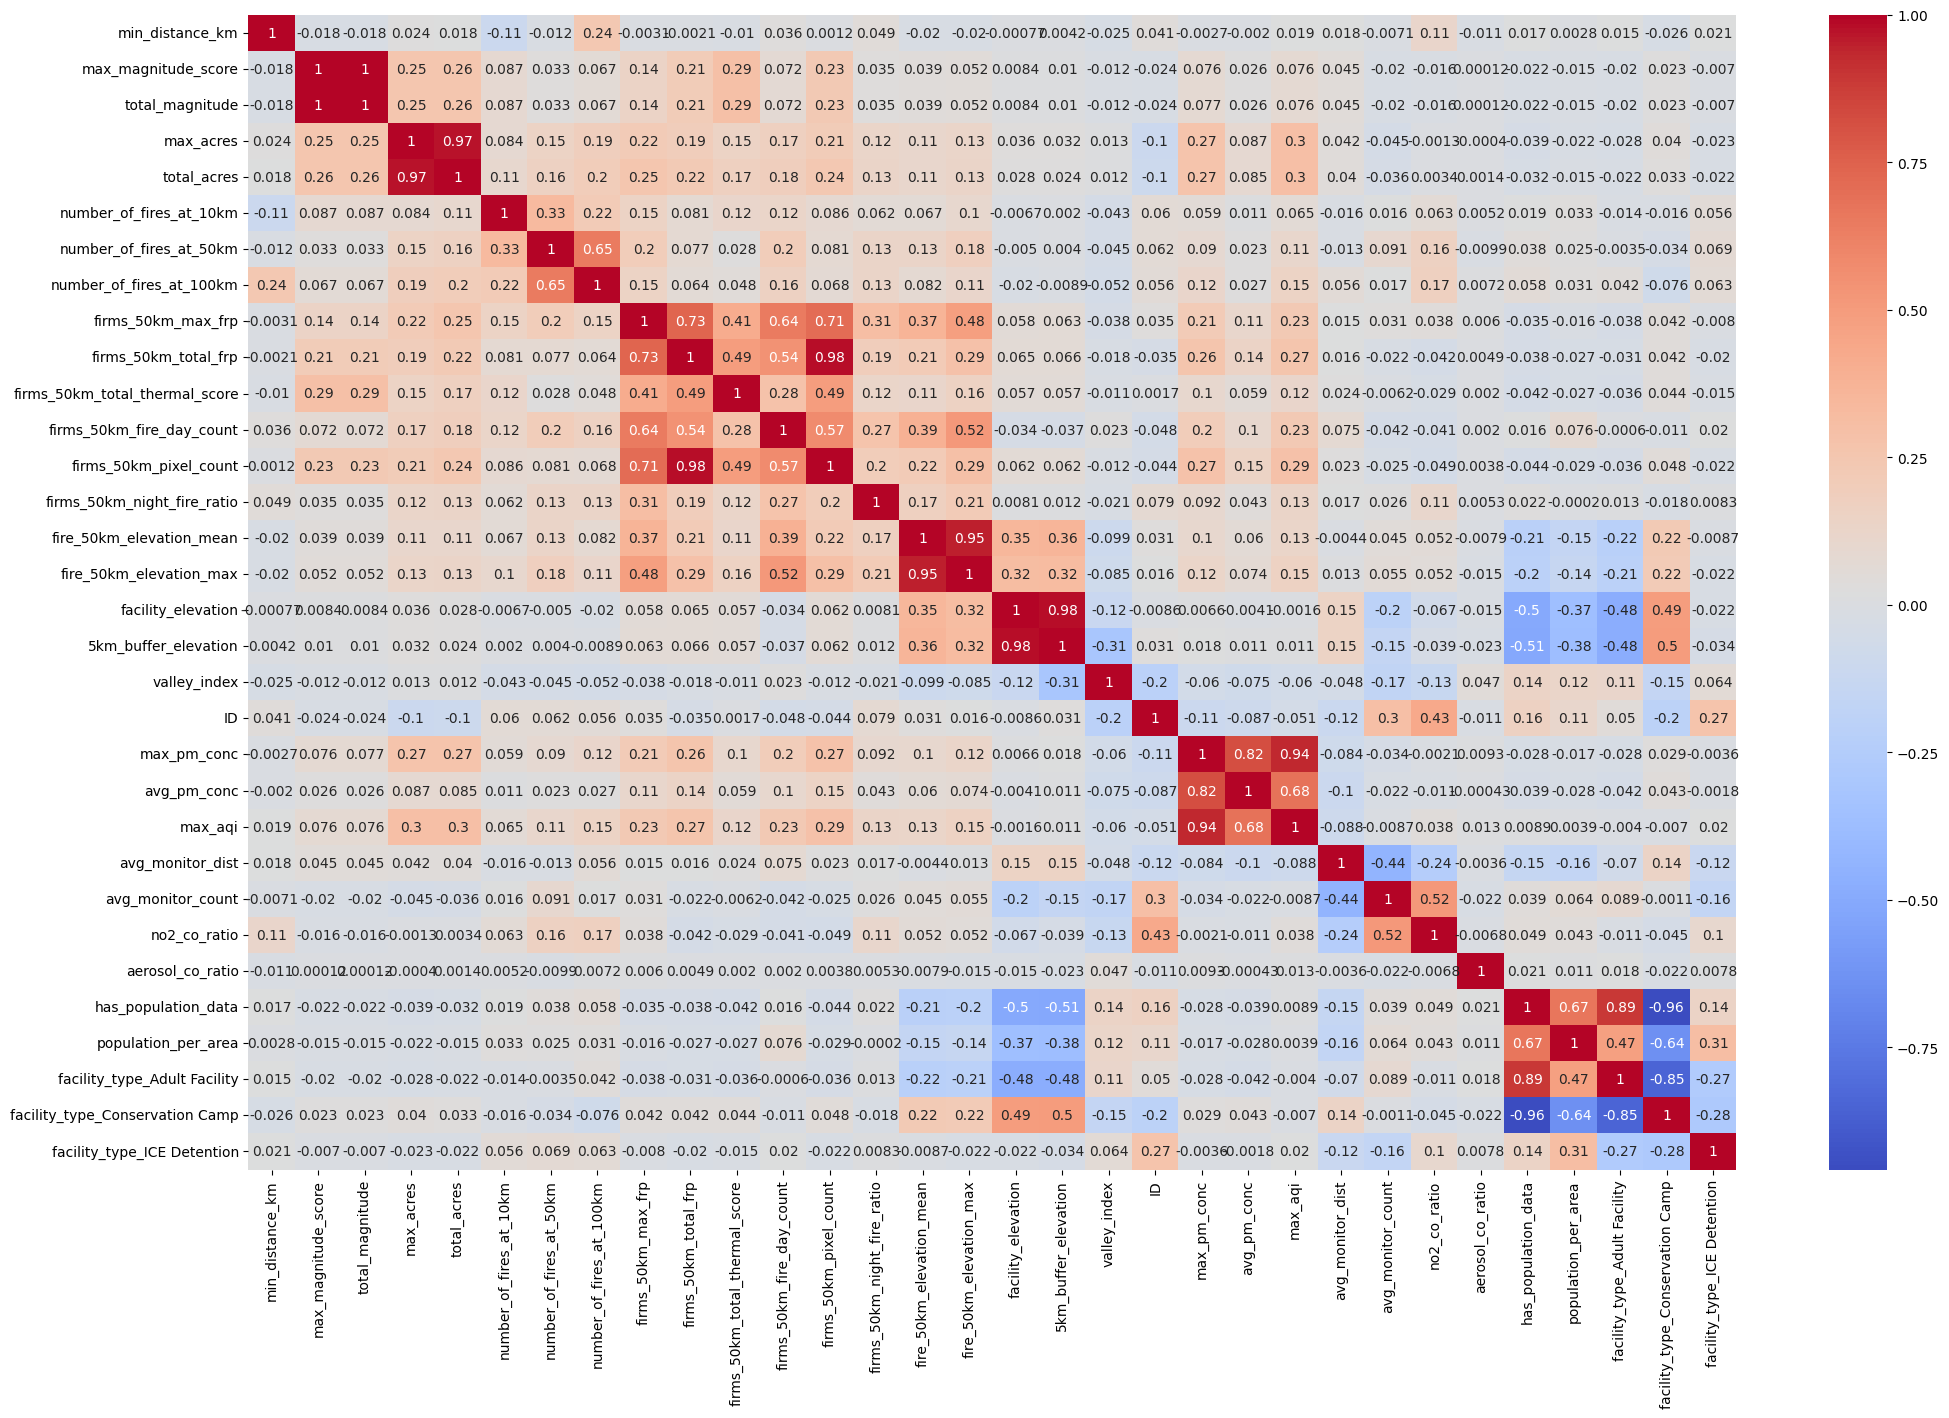

In [13]:
plt.figure(figsize=(24, 15))
correlation_points = finalizing_features_ohe_one.corr(numeric_only=True)
sns.heatmap(correlation_points, annot=True, cmap='coolwarm')
plt.show()

In [14]:
features_finalized_from_cm = finalizing_features_ohe_one.drop(columns=['total_magnitude', 'total_acres', 'firms_50km_total_frp',
                                                                  'firms_50km_pixel_count', 'fire_50km_elevation_mean',
                                                                  '5km_buffer_elevation', 'avg_pm_conc', 'max_aqi', 
                                                                  'has_population_data', 'facility_type_Conservation Camp']).copy()
features_finalized_from_cm

,Institution Name,Date,min_distance_km,max_magnitude_score,max_acres,number_of_fires_at_10km,number_of_fires_at_50km,number_of_fires_at_100km,firms_50km_max_frp,firms_50km_total_thermal_score,...,valley_index,ID,max_pm_conc,avg_monitor_dist,avg_monitor_count,no2_co_ratio,aerosol_co_ratio,population_per_area,facility_type_Adult Facility,facility_type_ICE Detention
0,Avenal State Prison (ASP),2024-09,20.445998,11.512470,17614.501953,0.0,3.0,10.0,135.46,3.435115,...,-27.512706,37,11.10000,24680.020379,1.00000,0.002487,0.052432,0.010326,1.0,0.0
1,Avenal State Prison (ASP),2024-08,47.761541,0.013578,93.720016,0.0,1.0,6.0,0.00,0.000000,...,-27.512706,37,15.40000,24680.020379,1.00000,0.002738,0.042924,0.010816,1.0,0.0
2,Avenal State Prison (ASP),2024-10,58.614185,0.002694,14.273177,0.0,0.0,6.0,130.86,88.895563,...,-27.512706,37,NaN,NaN,NaN,0.002230,0.065429,0.009901,1.0,0.0
3,Avenal State Prison (ASP),2024-01,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00,0.000000,...,-27.512706,37,16.90000,24680.020379,1.00000,0.001546,-0.089753,0.011514,1.0,0.0
4,Avenal State Prison (ASP),2024-03,0.000000,0.000000,0.000000,0.0,0.0,0.0,33.43,0.023573,...,-27.512706,37,6.10000,24680.020379,1.00000,0.001765,-0.166920,0.011707,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5232,Otay Mesa Detention Center,2024-09,52.603041,0.084247,856.154236,0.0,0.0,3.0,166.44,4.053906,...,-35.998948,73,13.06250,498.496428,8.00000,0.002989,0.187392,0.047310,0.0,1.0
5233,Otay Mesa Detention Center,2024-10,47.047573,0.167037,411.360443,0.0,2.0,0.0,76.25,0.311930,...,-35.998948,73,NaN,NaN,NaN,0.003416,0.297662,0.050322,0.0,1.0
5234,Otay Mesa Detention Center,2024-11,1.493342,11.075086,68.851067,1.0,1.0,2.0,66.76,0.358535,...,-35.998948,73,NaN,NaN,NaN,0.004138,0.392720,0.052000,0.0,1.0
5235,Otay Mesa Detention Center,2024-12,20.013669,0.050034,22.093618,0.0,1.0,0.0,47.55,0.151767,...,-35.998948,73,NaN,NaN,NaN,0.004539,-1.881984,0.052343,0.0,1.0


## Separating DataFrame as Containing all PM2.5 Data vs Missing PM2.5 Data 

In [15]:
# First sorting by date and separating date into Month and Year Columns
features_finalized_from_cm.sort_values(by="Date", ascending=True, inplace=True)
features_finalized_from_cm['Month'] = pd.to_datetime(features_finalized_from_cm['Date']).dt.month
features_finalized_from_cm['Year'] = pd.to_datetime(features_finalized_from_cm['Date']).dt.year

final_features = features_finalized_from_cm.drop(columns=['Institution Name', 'Date']).copy()
final_features

,min_distance_km,max_magnitude_score,max_acres,number_of_fires_at_10km,number_of_fires_at_50km,number_of_fires_at_100km,firms_50km_max_frp,firms_50km_total_thermal_score,firms_50km_fire_day_count,firms_50km_night_fire_ratio,...,max_pm_conc,avg_monitor_dist,avg_monitor_count,no2_co_ratio,aerosol_co_ratio,population_per_area,facility_type_Adult Facility,facility_type_ICE Detention,Month,Year
1317,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,...,24.990000,8812.187109,4.741935,0.002332,-0.024122,0.026181,1.0,0.0,1,2020
2175,0.0,0.0,0.0,0.0,0.0,0.0,246.28,2.717090,10.0,0.0,...,21.600000,36229.033614,2.000000,0.001562,-0.026338,0.019975,1.0,0.0,1,2020
2947,0.0,0.0,0.0,0.0,0.0,0.0,10.98,0.015706,2.0,0.0,...,23.050000,28096.097109,6.741935,0.002589,-0.013992,0.000000,0.0,0.0,1,2020
3016,0.0,0.0,0.0,0.0,0.0,0.0,10.08,0.005403,1.0,0.0,...,15.992857,20670.395438,7.193548,0.002319,-0.022779,0.000000,0.0,0.0,1,2020
963,0.0,0.0,0.0,0.0,0.0,0.0,56.25,0.072888,1.0,0.0,...,29.475000,5269.800560,3.967742,0.002057,-0.029449,0.011348,1.0,0.0,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3636,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,...,6.966667,24024.625592,3.000000,0.003022,-0.053837,0.000000,0.0,0.0,9,2025
4740,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,...,7.525000,3368.906617,6.000000,0.002973,-1.334915,0.000000,0.0,0.0,9,2025
4326,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,...,9.584615,7695.360394,13.000000,0.003907,0.051627,0.000000,0.0,0.0,9,2025
1603,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,...,13.550000,37820.804416,2.000000,0.003000,0.091061,0.005296,1.0,0.0,9,2025


In [16]:
# Interpolating missing monitor count and average distance 
final_features['avg_monitor_dist'] = final_feature_engineered_data.groupby('ID')['avg_monitor_dist'].transform(lambda x: x.fillna(x.mean()))
final_features['avg_monitor_count'] = final_feature_engineered_data.groupby('ID')['avg_monitor_count'].transform(lambda x: x.fillna(x.mean()))

In [17]:
# Setting aside missing pm values to be inputted in model after it is established.
# Missing PM2.5 values resulted in no EPA or PurpleAir data recorded at the specified time frame and at the specified location
# either due to monitor not existing or other errors. 
missing_pm_values_indices = missing_pm_values_sorted.index

final_features_all_pm = final_features.drop(missing_pm_values_indices).copy()
#final_features_all_pm.to_pickle('final_features_all_pm.pkl')

In [18]:
final_features_missing_pm = final_features[final_features.index.isin(missing_pm_values_indices)].copy()
final_features_missing_pm.drop(columns='max_pm_conc', inplace=True)
#final_features_missing_pm.to_pickle('final_features_missing_pm.pkl')